# 第 6 天：Baseline、Suite 与 Leaderboard

用统一 task、seeds 和 metrics 比较不同策略，而不是只看一次高分。

今天学习 benchmark 的基本纪律：同一任务、同一预算、多个 seeds、可聚合指标，才能比较 random、LHS、scripted 和其他 agent。


## 学习路径定位

| 项目 | 内容 |
| --- | --- |
| 阶段 | B. 认识规律 |
| 难度 | 进阶 3/3 |
| 先修 | 知道 score、risk、sample efficiency 和 trajectory 的含义。 |
| 今天只解决 | 比较 random、LHS、scripted、BO、safe BO 等 baseline 的决策效率。 |
| 今天不要求 | 不把 leaderboard 当唯一目标，也不只看最终最高分。 |
| 本日交付 | baseline 对比表、best-score 曲线、安全成本解释。 |
| 下一步如何复用 | Day 7 会把你选定的策略整理成可复现 submission artifact。 |



## 课堂时间盒：每 30 分钟都有产出

建议按 3 小时工作坊使用。每一段都要留下一个小证据，不要只运行代码看到结果就继续往下翻。

| 时间 | 阶段目标 | 具体动作 | 当段产出 |
| --- | --- | --- | --- |
| 0:00-0:30 | 理解评测合同 | 查看 task、budget、seeds、metrics。 | 说明为什么不能只看一次最高分。 |
| 0:30-1:00 | 运行 random/scripted | 执行快速 baseline 并读取结果。 | 得到第一张 baseline 表。 |
| 1:00-1:30 | 运行 LHS/greedy | 比较系统探索和局部搜索。 | 指出两者优缺点。 |
| 1:30-2:00 | 理解 BO 预算 | 检查 campaign、final assay count 和 acquisition 阶段。 | 确认 BO 是否真正闭环。 |
| 2:00-2:30 | 聚合 leaderboard | 按 task 输出 performance、safety、sample efficiency。 | 得到榜单摘要。 |
| 2:30-3:00 | 写评测结论 | 解释哪个 baseline 强、哪个风险高、哪里还不公平。 | 形成评测备注。 |

教师提示：如果课堂时间少于 3 小时，可以把最后两个时间盒改成课后提交；但前四个时间盒建议现场完成。


## 本日任务梯度

| 层级 | 任务 |
| --- | --- |
| 基础任务 | 运行至少两个 baseline 并比较最终 score。 |
| 进阶任务 | 比较 area-under-best-score、invalid action 和 safety cost。 |
| 挑战任务 | 解释为什么某个策略在 public world 强，但可能泛化差。 |
| 反思问题 | 一个好 benchmark 为什么要同时看性能、样本效率、安全和复现性？ |



## 三小时实验工单（必须自己完成）

这一节不是演示输出，而是当天真正的工作量。请不要只从上到下运行已有单元；必须在后面的学生工作区新增自己的实验、图表、表格和文字结论。

| 序号 | 最小完成量 |
| --- | --- |
| 1 | 至少运行 5 类策略：random、LHS、scripted、BO、safe BO；每类至少 3 个 seed。 |
| 2 | 输出 performance、sample efficiency、safety cost、invalid action count 四类指标。 |
| 3 | 画 best-score 曲线和 safety-cost 曲线，解释两条曲线是否一致。 |
| 4 | 写 400 字 baseline 诊断：哪个策略最稳，哪个策略最容易刷榜但不安全。 |

验收口径：本日交付至少应包含数据表、图或谱图、验证/评测结果、机制解释和下一步实验建议。低于这些证据量，视为只完成了演示浏览。



## 学生工作区

请从这里开始写自己的实验扩展。建议保留上方演示单元作为参考，不要直接覆盖；把你新增的实验条件、图、模型、验证结果和文字结论放在下面。

建议你在本节下面新增自己的代码单元。可从这个记录模板开始：

```python
student_work = {
    "hypothesis": "",
    "experiments_added": 0,
    "figures_created": 0,
    "verification_or_metric": "",
    "next_experiment": "",
}
```



In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(6)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)

project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day06


## 今日任务

请先运行顶部导入单元，确认 kernel 指向项目虚拟环境；随后按顺序执行每个代码单元，观察表格、图形和验证结果，并在最后写下自己的实验判断。


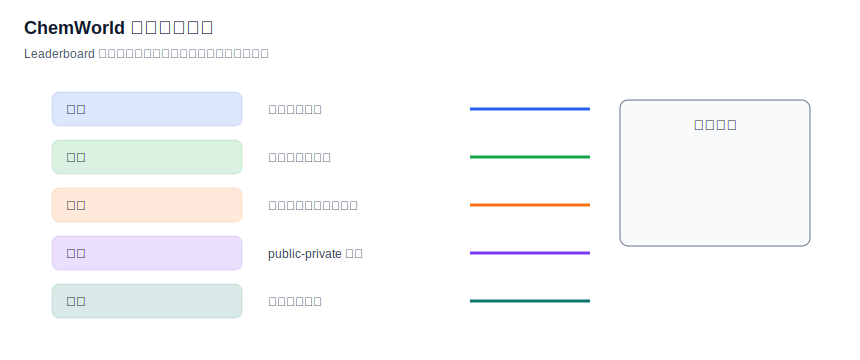

In [2]:
tu.display_tutorial_header(
    day=6,
    title='Baseline、Suite 与 Leaderboard',
    subtitle='用统一 task、seeds 和 metrics 比较不同策略，而不是只看一次高分。',
    focus=[
        'random/LHS/scripted baselines',
        'suite runner',
        'leaderboard 聚合',
        'public-private gap',
    ],
    deliverables=[
        '一张 baseline leaderboard',
        '一份 gap 诊断',
        '一条公平性说明',
    ],
    project_link='共享世界挑战需要多榜并行，防止单一总分掩盖风险和泛化问题。',
)
tu.display_course_map(6)
display(tu.leaderboard_blueprint_svg())


In [3]:
tu.display_api_card()

## 第 6 天检查点

完成本 notebook 后，请确认你已经留下这些证据：

- 一张来自自己实验的轨迹表或 JSONL 文件
- 一张由自己实验数据生成的图
- 一个有化工意义的机制假设
- 一个下一轮实验建议
- 一条关于 GPT 或其他助手使用方式的记录


In [5]:
from chemworld.eval.leaderboard import aggregate_leaderboard
from chemworld.eval.suite import run_suite

teaching_seeds = list(range(5))
formal_benchmark_seeds = list(range(30))
agents = ["random", "scripted_chemistry", "lhs", "gp_bo", "safe_gp_bo"]
suite_results = []
for agent_name in agents:
    suite_results.extend(
        run_suite(
            agent_name=agent_name,
            env_id="ChemWorld",
            world_splits=["public-test", "private-eval"],
            seeds=teaching_seeds,
            budget=66,
            objective="balanced",
            output_dir=OUTPUT_DIR / agent_name,
        )
    )

leaderboard = pd.DataFrame(aggregate_leaderboard(suite_results))
wide_leaderboard = tu.leaderboard_wide(leaderboard)
display(
    leaderboard[
        [
            "rank",
            "agent_name",
            "world_split",
            "runs",
            "mean_total_score",
            "sem_total_score",
            "ci95_total_score_low",
            "ci95_total_score_high",
            "mean_safety_aware_score",
            "public_private_gap",
        ]
    ]
)
display(wide_leaderboard)
print("Teaching run seeds:", teaching_seeds)
print("Formal benchmark target seeds:", len(formal_benchmark_seeds))

,rank,agent_name,world_split,runs,mean_total_score,sem_total_score,ci95_total_score_low,ci95_total_score_high,mean_safety_aware_score,public_private_gap
0,1,scripted_chemistry,private-eval,5,0.1935,0.0419,0.1114,0.2755,0.2354,-0.0578
1,2,latin_hypercube,private-eval,5,0.1498,0.0832,0.0000,0.3129,0.1792,-0.0788
2,3,scripted_chemistry,public-test,5,0.1357,0.0491,0.0394,0.2320,0.1619,-0.0578
3,4,gp_bo,private-eval,5,0.1152,0.0580,0.0016,0.2288,0.1282,-0.0285
4,5,safe_gp_bo,private-eval,5,0.1152,0.0580,0.0016,0.2288,0.1282,-0.0285
5,6,gp_bo,public-test,5,0.0866,0.0739,0.0000,0.2314,0.0995,-0.0285
6,7,safe_gp_bo,public-test,5,0.0866,0.0739,0.0000,0.2314,0.0995,-0.0285
7,8,latin_hypercube,public-test,5,0.0710,0.0489,0.0000,0.1668,0.0754,-0.0788
8,9,random,private-eval,5,0.0491,0.0210,0.0080,0.0902,0.0000,-0.0140
9,10,random,public-test,5,0.0351,0.0260,0.0000,0.0860,0.0000,-0.0140


,agent,public_score,private_score,public_private_gap,mean_safety_score,runs
0,scripted_chemistry,0.1357,0.1935,-0.0578,0.1987,10
1,latin_hypercube,0.0710,0.1498,-0.0788,0.1273,10
2,gp_bo,0.0866,0.1152,-0.0285,0.1139,10
3,safe_gp_bo,0.0866,0.1152,-0.0285,0.1139,10
4,random,0.0351,0.0491,-0.0140,0.0000,10


Teaching run seeds: [0, 1, 2, 3, 4]
Formal benchmark target seeds: 30


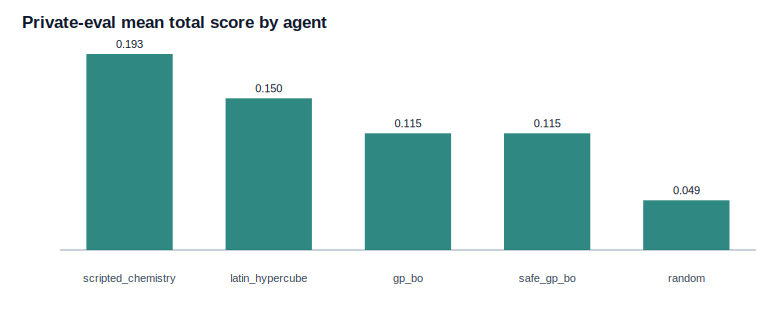

In [6]:
labels = [row.agent for row in wide_leaderboard.itertuples(index=False)]
display(
    tu.bar_svg(
        labels,
        wide_leaderboard["private_score"].astype(float).tolist(),
        title="Private-eval mean total score by agent",
        color="#0f766e",
    )
)

,label,yield,conversion,risk,score
0,safer,0.8233,0.9959,0.0868,0.6391
1,risky,0.0033,0.9961,0.5420,0.0000


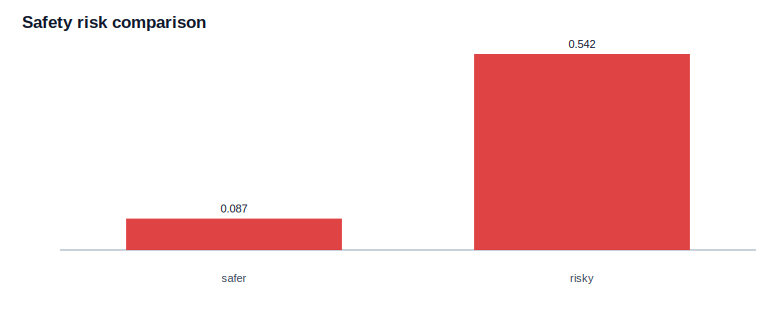

In [7]:
safe_recipe = {
    "temperature": 80.0,
    "time": 0.5,
    "initial_concentration": 0.35,
    "stirring_speed": 720.0,
    "catalyst": 1,
    "solvent": 1,
}
risky_recipe = {
    "temperature": 155.0,
    "time": 2.0,
    "initial_concentration": 1.80,
    "stirring_speed": 1000.0,
    "catalyst": 3,
    "solvent": 3,
}
risk_compare = pd.DataFrame(
    [
        dict(tu.run_recipe(safe_recipe, seed=66), label="safer"),
        dict(tu.run_recipe(risky_recipe, seed=66), label="risky"),
    ]
)
display(risk_compare[["label", "yield", "conversion", "risk", "score"]])
display(
    tu.bar_svg(
        risk_compare["label"].tolist(),
        risk_compare["risk"].astype(float).tolist(),
        title="Safety risk comparison",
        color="#dc2626",
    )
)

## 当天练习

看 leaderboard 时不要只看第一名。请选择一个 agent，回答：

- 它在 public-test 和 private-eval 上是否稳定？
- 它的 safety-aware score 是否明显低于 performance？
- 你会怎样改进它的探索策略？


## 课后反思

请用两三句话回答下面的问题，并把答案写进当天的实验日志。


In [8]:
tu.display_reflection_box(
    [
        'leaderboard 最容易诱导哪类刷榜行为？',
        '为什么不能只报告 final score？',
    ]
)
